# Module 7 Notes | PCA & Encoding Methods (Linear, Nonlinear, Deep)

This notebook demonstrates:

- PCA as a linear encoder
- Linear Autoencoder (equivalent to PCA)
- Nonlinear Autoencoder
- Deep Autoencoder

We'll be using a generated dataset for clairty

In [19]:
# Imports & Data
%pip install numpy matplotlib scikit-learn tensorflow
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

import tensorflow as tf
from tensorflow.keras import layers, Model

Note: you may need to restart the kernel to use updated packages.


## Generate Nonlinear Data (Swiss Roll)
Swiss roll is perfect for comparing
- Linear Methods (PCA, Linear AE)
- Nonlinear methods (Nonlinear & Deep AEs)


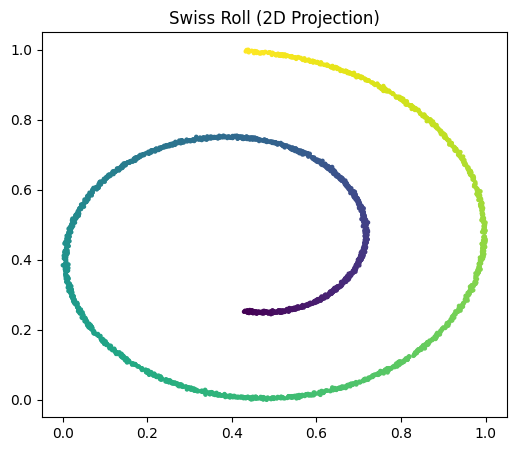

In [20]:
X, t = make_swiss_roll(n_samples=3000, noise=0.05)
X = X[:, [0,2]] # use x and z only for 2D cisual clarity

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
plt.figure(figsize=(6,5))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=t, cmap="viridis", s=5)
plt.title("Swiss Roll (2D Projection)")
plt.show()

# PCA Encoding
PCA is a purely **linear** dimensionality reduction method
- computes covariance
- finds eigenvectors (principal components)
- projects data onto those components

In [21]:
pca = PCA(n_components=1)
Z_pca = pca.fit_transform(X_scaled)
X_recon_pca = pca.inverse_transform(Z_pca)

print("Z_pca shape:", Z_pca.shape)

Z_pca shape: (3000, 1)


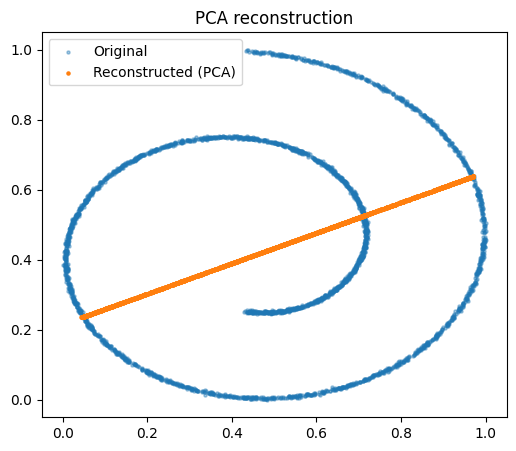

In [22]:
plt.figure(figsize=(6,5))
plt.scatter(X_scaled[:,0], X_scaled[:,1], s=5, label="Original", alpha=0.4)
plt.scatter(X_recon_pca[:,0], X_recon_pca[:,1], s=5 , label ="Reconstructed (PCA)")
plt.legend()
plt.title("PCA reconstruction")
plt.show()

# Linear Autoencoder (Linear Encoding)

A Linear autoencoder replicates PCA when:
- no activation function (purely linear)
- bottleneck dimension = PCA components
- trained with MSE

Architecture:
Input - Dense(k) - Dense(original_dim)

In [23]:
input_dim = X_scaled.shape[1]
latent_dim = 1

inputs = layers.Input(shape=(input_dim,))
encoded = layers.Dense(latent_dim, activation=None)(inputs)
decoded = layers.Dense(input_dim, activation=None)(encoded)

linear_ae = Model(inputs, decoded)
linear_ae.compile(optimizer="adam", loss="mse")

linear_ae.fit(X_scaled, X_scaled, epochs=50, batch_size=32, verbose=0)

Z_lin = Model(inputs, encoded).predict(X_scaled)
X_recon_lin = linear_ae.predict(X_scaled)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 317us/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 366us/step


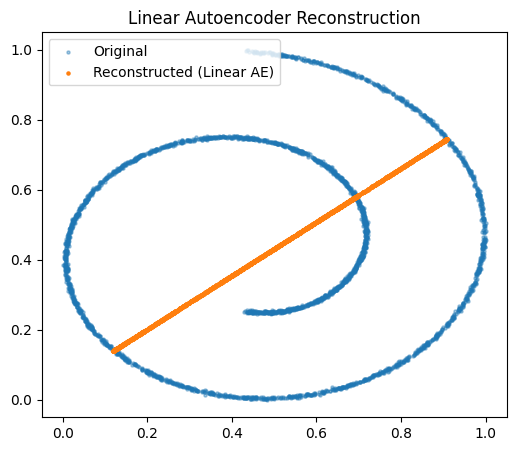

In [24]:
plt.figure(figsize=(6,5))
plt.scatter(X_scaled[:, 0], X_scaled[:,1], s=5, label="Original", alpha=0.4)
plt.scatter(X_recon_lin[:,0], X_recon_lin[:,1], s=5, label = "Reconstructed (Linear AE)")
plt.legend()
plt.title("Linear Autoencoder Reconstruction")
plt.show()

# Nonlinear Autoencoder

Adds a nonlinear activation function (ReLU, tanh, etc.) to learn **curved** data structures.

Architecture 
Input - Dense(32 ReLU) - Dense(latent) - Dense(32 EwLU) Output

It can capture nonlinear manifolds that PCA cannot.

In [25]:
inputs = layers.Input(shape=(input_dim,))
encoded = layers.Dense(32, activation="relu")(inputs)
encoded = layers.Dense(latent_dim, activation="relu")(encoded)

decoded = layers.Dense(32, activation="relu")(encoded)
decoded = layers.Dense(input_dim, activation="sigmoid")(decoded)

nonlinear_ae = Model(inputs, decoded)
nonlinear_ae.compile(optimizer="adam", loss="mse")

nonlinear_ae.fit(X_scaled, X_scaled, epochs=50, batch_size=32, verbose=0)

Z_nl = Model(inputs, encoded).predict(X_scaled)
X_recon_nl = nonlinear_ae.predict(X_scaled)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 405us/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 454us/step


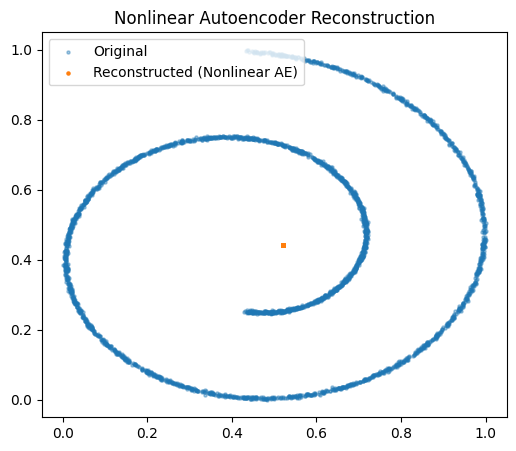

In [26]:
plt.figure(figsize=(6,5))
plt.scatter(X_scaled[:,0], X_scaled[:,1], s=5, label="Original", alpha=0.4)
plt.scatter(X_recon_nl[:,0], X_recon_nl[:,1], s=5, label="Reconstructed (Nonlinear AE)")
plt.legend()
plt.title("Nonlinear Autoencoder Reconstruction")
plt.show()

# Deep Autoencoder (Deep Nonlinear Encoding)

Multiple layers give far more representational power

Encoder:
- Dense(128)
- Dense(64)
- Dense(32)
- Latent(2)

Decoder mirrors the encoder

Used for:
- denoising
- feature extraction
- anamoly detection
- compression

In [27]:
latent_dim = 2

# Encoder
inputs = layers.Input(shape=(input_dim,))
x = layers.Dense(128, activation="relu")(inputs)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dense(32, activation="relu")(x)
latent = layers.Dense(latent_dim, activation="relu")(x)

# Decoder
x = layers.Dense(32, activation="relu")(latent)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dense(128, activation="relu")(x)
outputs = layers.Dense(input_dim, activation="sigmoid")(x)

deep_ae = Model(inputs, outputs)
deep_ae.compile(optimizer="adam", loss="mse")

deep_ae.fit(X_scaled, X_scaled, epochs=50, batch_size=32, verbose=0)

encoder = Model(inputs, latent)
Z_deep = encoder.predict(X_scaled)
X_recon_deep = deep_ae.predict(X_scaled)




94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 471us/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 641us/step


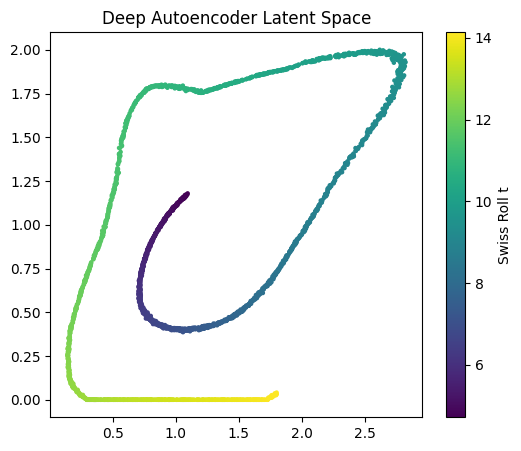

In [31]:
plt.figure(figsize=(6,5))
plt.scatter(Z_deep[:,0], Z_deep[:,1], c=t, cmap="viridis", s=5)
plt.title("Deep Autoencoder Latent Space")
plt.colorbar(label="Swiss Roll t")
plt.show()

# Summary Comparison

| Method | Linear? | Nonlinear? | Power | Notes |
|--------|---------|------------|--------|-------|
| PCA | Yes | No | Low | Fast, interpretable, classical |
| Linear Autoencoder | Yes | No | Low | Neural PCA |
| Nonlinear AE | No | Yes | Medium | Learns curved manifolds |
| Deep AE | No | Yes | High | Best expressive power |

Deep AEs give the best results on complex data.
